In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics
import matplotlib as plt
import seaborn as sns


In [59]:
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

In [48]:
df.shape

(100000, 9)

In [49]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [50]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [51]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [52]:
df = df.drop_duplicates()

In [53]:
df.shape

(96146, 9)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


In [54]:
smoking_map = {
    'never': 0,
    'No Info': 1,
    'former': 2,
    'not current': 3,
    'ever': 4,
    'current': 5
}

df['smoking_history'] = df['smoking_history'].map(smoking_map)


In [55]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,0,25.19,6.6,140,0
1,Female,54.0,0,0,1,27.32,6.6,80,0
2,Male,28.0,0,0,0,27.32,5.7,158,0
3,Female,36.0,0,0,5,23.45,5.0,155,0
4,Male,76.0,1,1,5,20.14,4.8,155,0


In [23]:
df['gender'] = df['gender'].replace({'Male': 0, 'Female': 1})

C:\Users\Atharva\AppData\Local\Temp\ipykernel_4240\4209017409.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gender'] = df['gender'].replace({'Male': 0, 'Female': 1})


In [25]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,80.0,0,1,never,25.19,6.6,140,0
1,1,54.0,0,0,No Info,27.32,6.6,80,0
2,0,28.0,0,0,never,27.32,5.7,158,0
3,1,36.0,0,0,current,23.45,5.0,155,0
4,0,76.0,1,1,current,20.14,4.8,155,0


In [26]:
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [29]:
from sklearn.preprocessing import OneHotEncoder

In [30]:
ohe = OneHotEncoder(drop='first', sparse=False)
encoded = ohe.fit_transform(df[['smoking_history']])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['smoking_history'])
)

df = pd.concat([df.drop('smoking_history', axis=1), encoded_df], axis=1)

C:\Users\Atharva\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [31]:
df.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,1,80.0,0.0,1.0,25.19,6.6,140.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,54.0,0.0,0.0,27.32,6.6,80.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,28.0,0.0,0.0,27.32,5.7,158.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,36.0,0.0,0.0,23.45,5.0,155.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,76.0,1.0,1.0,20.14,4.8,155.0,0.0,1.0,0.0,0.0,0.0,0.0


In [32]:
df = df[['gender', 'age',	'hypertension',	'heart_disease',	'bmi',	'HbA1c_level',	'blood_glucose_level',	'smoking_history_current',	'smoking_history_ever',	'smoking_history_former',	'smoking_history_never',	'smoking_history_not current', 'diabetes']]

In [33]:
df.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,diabetes
0,1,80.0,0.0,1.0,25.19,6.6,140.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,54.0,0.0,0.0,27.32,6.6,80.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,28.0,0.0,0.0,27.32,5.7,158.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1,36.0,0.0,0.0,23.45,5.0,155.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,76.0,1.0,1.0,20.14,4.8,155.0,1.0,0.0,0.0,0.0,0.0,0.0


In [38]:
df['gender'].unique()

array([1, 0, 'Other', nan], dtype=object)

In [45]:
df.isnull().sum()

Series([], dtype: float64)

In [46]:
df.shape

(99731, 0)

In [44]:
df = df.dropna(axis = True)

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [56]:
df['gender'] = df['gender'].astype(str)
df['gender'] = le.fit_transform(df['gender'])

In [63]:
correlation = df.corr()

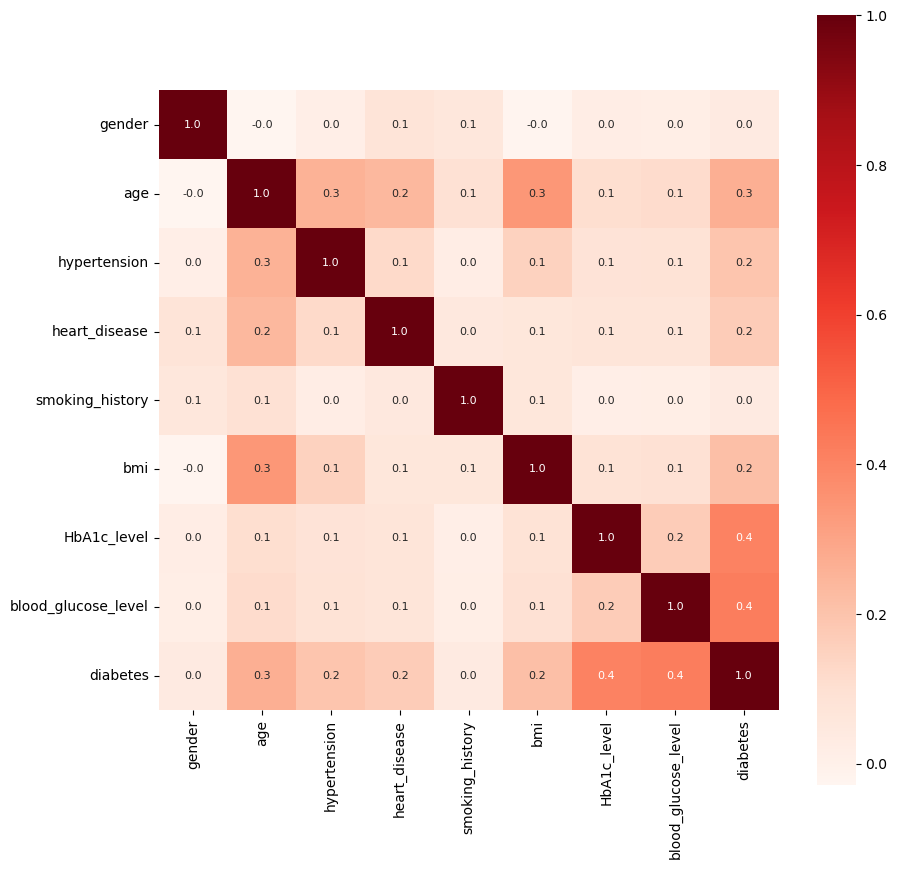

In [66]:
plt.figure(figsize = (10, 10))

sns.heatmap(correlation, annot = True, cmap = "Reds", cbar = True, square = True, fmt = '.1f', annot_kws= {'size':8})

plt.show()

In [67]:
x = df.drop(['diabetes'], axis = 1)
y = df['diabetes']

In [68]:
model = XGBRegressor()

In [70]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

In [71]:
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [72]:
training_data_prediction = model.predict(x_train)

In [73]:
score1 = metrics.r2_score(y_train, training_data_prediction)

score2 = metrics.mean_absolute_error(y_train, training_data_prediction)

print(score1)
print(score2)

0.7658159143652739
0.04828849231026449


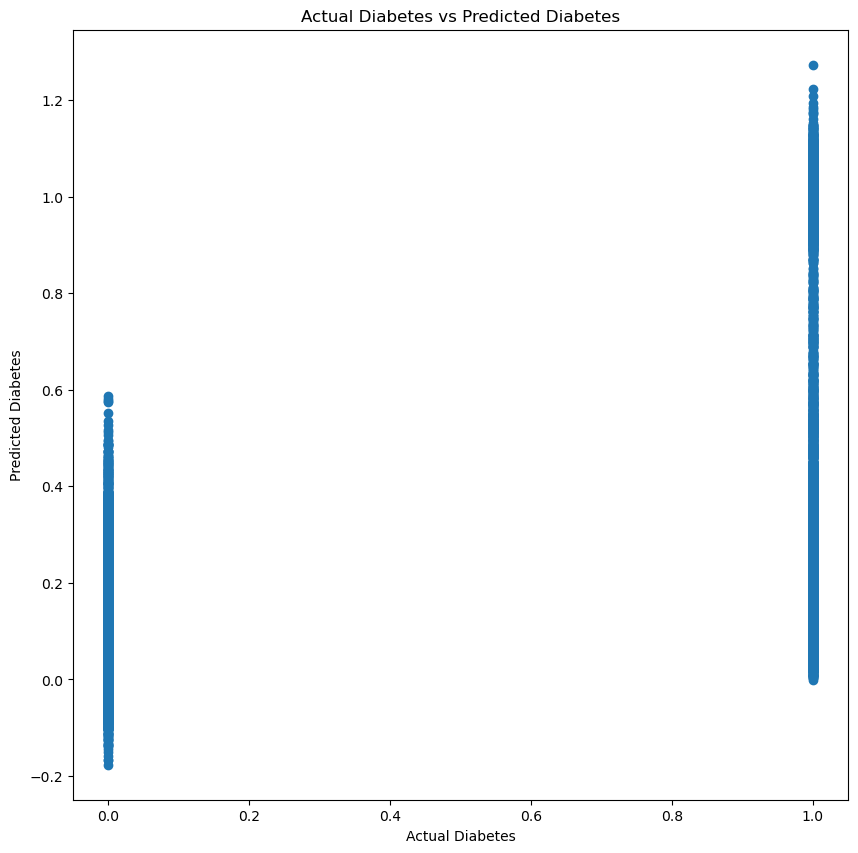

In [74]:
plt.figure(figsize = (10, 10))
plt.scatter(y_train, training_data_prediction)
plt.xlabel('Actual Diabetes')
plt.ylabel('Predicted Diabetes')
plt.title('Actual Diabetes vs Predicted Diabetes')
plt.show()